In [1]:
!pip install diffusers accelerate -q
# Cell 1: Setup and Mounting
from google.colab import drive
import os

print("✅ Drive mounted and dependencies installed.")

✅ Drive mounted and dependencies installed.


In [2]:
# Cell 2: Imports, Config, and Dataset
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from diffusers import UNet2DModel, DDPMScheduler
from diffusers.optimization import get_cosine_schedule_with_warmup
from tqdm.auto import tqdm
import time
import csv
import os
from google.colab import files

# --- CONFIGURATION ---
# UPDATE THIS BASE PATH TO WHERE YOU UPLOADED THE FOLDER ON DRIVE
BASE_DRIVE_PATH = "/content/drive/MyDrive/Dataset-Gen/Processed_BraTS_AnomalyDetection"

TRAIN_DIR = os.path.join(BASE_DRIVE_PATH, "Train/Healthy")
VAL_DIR = os.path.join(BASE_DRIVE_PATH, "Val/Healthy") # We only validate on healthy data!
CHECKPOINT_DIR = "/content/drive/MyDrive/Diffusion_Checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

IMAGE_SIZE = 224
BATCH_SIZE = 6
NUM_EPOCHS = 50
LEARNING_RATE = 1e-4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- DATASET ---
class HealthyBrainDataset(Dataset):
    def __init__(self, image_dir, image_size):
        self.image_paths = [os.path.join(image_dir, f) for f in os.listdir(image_dir) if f.endswith('.png')]
        self.transform = transforms.Compose([
            transforms.Grayscale(num_output_channels=1),
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5])
        ])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        return self.transform(Image.open(self.image_paths[idx]))

# Load Train Data
train_dataset = HealthyBrainDataset(TRAIN_DIR, IMAGE_SIZE)
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)

# Load Validation Data
val_dataset = HealthyBrainDataset(VAL_DIR, IMAGE_SIZE)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Loaded {len(train_dataset)} Train images and {len(val_dataset)} Validation images.")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Using device: cuda
Loaded 4461 Train images and 911 Validation images.


In [ ]:
# Cell 3: Model, Resumable Training Loop, and Drive Logging
import glob

# 1. Initialize Model
model = UNet2DModel(
    sample_size=IMAGE_SIZE,
    in_channels=1, out_channels=1,
    layers_per_block=2,
    block_out_channels=(128, 128, 256, 256, 512, 512),
    down_block_types=("DownBlock2D", "DownBlock2D", "DownBlock2D", "DownBlock2D", "AttnDownBlock2D", "DownBlock2D"),
    up_block_types=("UpBlock2D", "AttnUpBlock2D", "UpBlock2D", "UpBlock2D", "UpBlock2D", "UpBlock2D"),
).to(device)

noise_scheduler = DDPMScheduler(num_train_timesteps=1000)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
lr_scheduler = get_cosine_schedule_with_warmup(
    optimizer=optimizer, num_warmup_steps=500, num_training_steps=(len(train_dataloader) * NUM_EPOCHS)
)

csv_path = os.path.join(CHECKPOINT_DIR, "training_metrics.csv")
best_val_loss = float('inf')
start_epoch = 0

# 2. RESUME LOGIC: Check for existing checkpoints
checkpoint_files = glob.glob(os.path.join(CHECKPOINT_DIR, "checkpoint_epoch_*.pt"))

if checkpoint_files:
    # Find the most recent checkpoint by epoch number
    latest_checkpoint = max(checkpoint_files, key=os.path.getctime)
    print(f"🔄 Found existing checkpoint. Resuming from: {latest_checkpoint}")

    checkpoint = torch.load(latest_checkpoint, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    if 'scheduler_state_dict' in checkpoint:
        lr_scheduler.load_state_dict(checkpoint['scheduler_state_dict'])

    start_epoch = checkpoint['epoch']
    best_val_loss = checkpoint.get('val_loss', float('inf'))
else:
    print("🚀 Starting fresh training...")
    # Initialize CSV with headers if starting from scratch
    with open(csv_path, mode='w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(["Epoch", "Train_Loss", "Val_Loss", "Learning_Rate", "Time_s", "Peak_VRAM_MB"])

# 3. Training Loop
for epoch in range(start_epoch, NUM_EPOCHS):
    start_time = time.time()
    if torch.cuda.is_available(): torch.cuda.reset_peak_memory_stats()

    # --- TRAINING PHASE ---
    model.train()
    train_loss = 0.0
    train_bar = tqdm(total=len(train_dataloader), desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Train]", leave=False)

    for batch in train_dataloader:
        clean_images = batch.to(device)
        noise = torch.randn(clean_images.shape).to(device)
        bs = clean_images.shape[0]
        timesteps = torch.randint(0, noise_scheduler.config.num_train_timesteps, (bs,), device=device).long()

        noisy_images = noise_scheduler.add_noise(clean_images, noise, timesteps)
        noise_pred = model(noisy_images, timesteps, return_dict=False)[0]

        loss = F.mse_loss(noise_pred, noise)
        loss.backward()
        optimizer.step()
        lr_scheduler.step()
        optimizer.zero_grad()

        train_loss += loss.item()
        train_bar.update(1)
        train_bar.set_postfix(loss=f"{loss.item():.4f}")
    train_bar.close()

    # --- VALIDATION PHASE ---
    model.eval()
    val_loss = 0.0
    val_bar = tqdm(total=len(val_dataloader), desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Val]", leave=False)

    with torch.no_grad():
        for batch in val_dataloader:
            clean_images = batch.to(device)
            noise = torch.randn(clean_images.shape).to(device)
            bs = clean_images.shape[0]
            timesteps = torch.randint(0, noise_scheduler.config.num_train_timesteps, (bs,), device=device).long()

            noisy_images = noise_scheduler.add_noise(clean_images, noise, timesteps)
            noise_pred = model(noisy_images, timesteps, return_dict=False)[0]

            loss = F.mse_loss(noise_pred, noise)
            val_loss += loss.item()
            val_bar.update(1)
    val_bar.close()

    # --- Epoch Metrics & Logging ---
    avg_train_loss = train_loss / len(train_dataloader)
    avg_val_loss = val_loss / len(val_dataloader)
    epoch_time = time.time() - start_time
    current_lr = lr_scheduler.get_last_lr()[0]
    vram_mb = torch.cuda.max_memory_allocated() / (1024 * 1024) if torch.cuda.is_available() else 0

    print(f"✅ Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Time: {epoch_time:.1f}s | VRAM: {vram_mb:.1f}MB")

    # Always append to CSV on Drive
    with open(csv_path, mode='a', newline='') as file:
        writer = csv.writer(file)
        writer.writerow([epoch+1, f"{avg_train_loss:.6f}", f"{avg_val_loss:.6f}", f"{current_lr:.6f}", f"{epoch_time:.2f}", f"{vram_mb:.2f}"])

    # --- Saving Logic ---
    # 1. Continually overwrite the "Best Model" if validation improves
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_path = os.path.join(CHECKPOINT_DIR, "best_model")
        model.save_pretrained(best_model_path)
        print(f"🌟 New Best Model Saved to Drive! (Val Loss: {best_val_loss:.4f})")

    # 2. Save full state checkpoint ONLY every 10 epochs
    if (epoch + 1) % 3 == 0:
        checkpoint_path = os.path.join(CHECKPOINT_DIR, f"checkpoint_epoch_{epoch+1}.pt")
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': lr_scheduler.state_dict(),
            'train_loss': avg_train_loss,
            'val_loss': avg_val_loss,
        }, checkpoint_path)
        print(f"💾 Full Checkpoint saved to Drive at Epoch {epoch+1}")

🔄 Found existing checkpoint. Resuming from: /content/drive/MyDrive/Diffusion_Checkpoints/checkpoint_epoch_12.pt


Epoch 13/50 [Train]:   0%|          | 0/744 [00:00<?, ?it/s]

Loading best model from Drive...
Reconstructing image from timestep 500...


  0%|          | 0/500 [00:00<?, ?it/s]

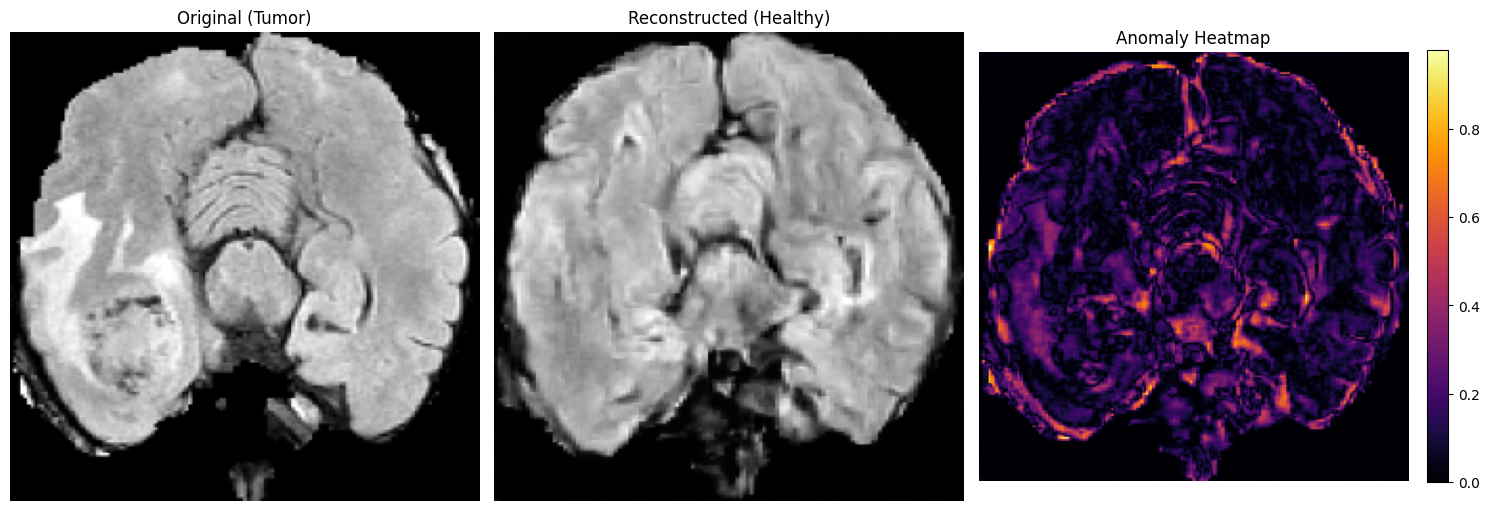

In [ ]:
import torch
import os
import random
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from diffusers import UNet2DModel, DDPMScheduler
from tqdm.auto import tqdm

# --- 1. CONFIGURATION ---
CHECKPOINT_DIR = "/content/drive/MyDrive/Diffusion_Checkpoints/best_model"
# Point this to your folder containing the tumor images
ABNORMAL_DIR = "/content/drive/MyDrive/Dataset-Gen/Processed_BraTS_AnomalyDetection/Test/Abnormal"

IMAGE_SIZE = 224
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 2. LOAD MODEL & SCHEDULER ---
print("Loading best model from Drive...")
model = UNet2DModel.from_pretrained(CHECKPOINT_DIR).to(device)
model.eval()

scheduler = DDPMScheduler(num_train_timesteps=1000)

# --- 3. PREPARE TEST IMAGE ---
# Pick a random abnormal image
abnormal_images = [f for f in os.listdir(ABNORMAL_DIR) if f.endswith('.png')]
test_img_path = os.path.join(ABNORMAL_DIR, random.choice(abnormal_images))

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

original_pil = Image.open(test_img_path)
input_tensor = transform(original_pil).unsqueeze(0).to(device) # Add batch dimension

# --- 4. THE ANOMALY DETECTION PROCESS ---
# Step A: Add noise up to a specific timestep (e.g., t=500 out of 1000)
# We don't want to destroy the image completely, just enough to erase the tumor details
t_start = 500
timesteps = torch.tensor([t_start], device=device).long()
noise = torch.randn_like(input_tensor)
noisy_image = scheduler.add_noise(input_tensor, noise, timesteps)

# Step B: Denoise it back to t=0
print(f"Reconstructing image from timestep {t_start}...")
reconstructed = noisy_image.clone()

scheduler.set_timesteps(1000)
# Iterate backwards from t_start to 0
for t in tqdm(scheduler.timesteps[1000 - t_start:]):
    with torch.no_grad():
        noise_pred = model(reconstructed, t).sample

    # Step backwards
    reconstructed = scheduler.step(noise_pred, t, reconstructed).prev_sample

# --- 5. CALCULATE HEATMAP & VISUALIZE ---
# Convert tensors back to visual format [0, 1]
orig_img_display = (input_tensor.squeeze() / 2 + 0.5).cpu().numpy()
recon_img_display = (reconstructed.squeeze() / 2 + 0.5).cpu().numpy()

# Anomaly Map is the absolute difference: |Original - Reconstructed|
anomaly_map = abs(orig_img_display - recon_img_display)

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(orig_img_display, cmap='gray')
axes[0].set_title("Original (Tumor)")
axes[0].axis('off')

axes[1].imshow(recon_img_display, cmap='gray')
axes[1].set_title("Reconstructed (Healthy)")
axes[1].axis('off')

# Use a heatmap colormap (like 'jet' or 'inferno') for the difference
im = axes[2].imshow(anomaly_map, cmap='inferno')
axes[2].set_title("Anomaly Heatmap")
axes[2].axis('off')

plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

Complete Evals : For the whole test data

In [ ]:
import torch
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from diffusers import UNet2DModel, DDIMScheduler
from tqdm.auto import tqdm
from sklearn.metrics import roc_auc_score, accuracy_score, precision_recall_fscore_support

# --- 1. CONFIGURATION ---
CHECKPOINT_DIR = "/content/drive/MyDrive/Diffusion_Checkpoints/best_model"

TEST_HEALTHY_DIR = "/content/drive/MyDrive/Dataset-Gen/Processed_BraTS_AnomalyDetection/Test/Healthy"
TEST_ABNORMAL_DIR = "/content/drive/MyDrive/Dataset-Gen/Processed_BraTS_AnomalyDetection/Test/Abnormal"

IMAGE_SIZE = 224
MAX_IMAGES_PER_CLASS = None  # None evaluates the whole dataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 2. LOAD MODEL & DDIM SCHEDULER ---
print(f"Loading best model to {device}...")
model = UNet2DModel.from_pretrained(CHECKPOINT_DIR).to(device)
model.eval()

# Swap DDPM for DDIM to speed up inference by 20x
scheduler = DDIMScheduler(num_train_timesteps=1000)

# Set total inference steps to 50 instead of 1000
INFERENCE_STEPS = 50
scheduler.set_timesteps(INFERENCE_STEPS)

# We want to start 50% of the way through the noise schedule
# 50% of 50 steps is index 25
START_STEP_INDEX = 25
t_start = scheduler.timesteps[START_STEP_INDEX]

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

# --- 3. HELPER FUNCTION FOR INFERENCE ---
def process_image(img_path):
    original_pil = Image.open(img_path)
    input_tensor = transform(original_pil).unsqueeze(0).to(device)

    # Add noise up to our target timestep
    noise = torch.randn_like(input_tensor)
    noisy_image = scheduler.add_noise(input_tensor, noise, torch.tensor([t_start], device=device))

    # Denoise using DDIM skipping
    reconstructed = noisy_image.clone()

    # Iterate backwards starting only from our injection point
    for t in scheduler.timesteps[START_STEP_INDEX:]:
        with torch.no_grad():
            noise_pred = model(reconstructed, t).sample

        # DDIM step
        reconstructed = scheduler.step(noise_pred, t, reconstructed).prev_sample

    # Calculate Anomaly Score (Mean Absolute Error)
    orig_np = (input_tensor.squeeze() / 2 + 0.5).cpu().numpy()
    recon_np = (reconstructed.squeeze() / 2 + 0.5).cpu().numpy()
    anomaly_map = np.abs(orig_np - recon_np)

    anomaly_score = np.mean(anomaly_map)
    return orig_np, recon_np, anomaly_map, anomaly_score

# --- 4. GATHER DATA ---
healthy_files = [os.path.join(TEST_HEALTHY_DIR, f) for f in os.listdir(TEST_HEALTHY_DIR) if f.endswith('.png')]
abnormal_files = [os.path.join(TEST_ABNORMAL_DIR, f) for f in os.listdir(TEST_ABNORMAL_DIR) if f.endswith('.png')]

if MAX_IMAGES_PER_CLASS:
    healthy_files = healthy_files[:MAX_IMAGES_PER_CLASS]
    abnormal_files = abnormal_files[:MAX_IMAGES_PER_CLASS]

all_files = healthy_files + abnormal_files
# Labels: 0 for Healthy, 1 for Abnormal
true_labels = [0] * len(healthy_files) + [1] * len(abnormal_files)

anomaly_scores = []
saved_visuals = []

print(f"Starting DDIM evaluation on {len(all_files)} images...")
for i, file_path in enumerate(tqdm(all_files, desc="Evaluating")):
    orig, recon, a_map, score = process_image(file_path)
    anomaly_scores.append(score)

    # Save 5 random abnormal visuals for the final plot
    if true_labels[i] == 1 and len(saved_visuals) < 5 and random.random() < 0.1:
        saved_visuals.append((orig, recon, a_map))

# Failsafe: Ensure we have 5 visuals
while len(saved_visuals) < 5 and len(all_files) > 0:
    saved_visuals.append((orig, recon, a_map))

# --- 5. CALCULATE METRICS ---
y_true = np.array(true_labels)
y_scores = np.array(anomaly_scores)

auroc = roc_auc_score(y_true, y_scores)

# Calculate dynamic threshold
healthy_mean_score = np.mean(y_scores[y_true == 0])
abnormal_mean_score = np.mean(y_scores[y_true == 1])
threshold = (healthy_mean_score + abnormal_mean_score) / 2

y_pred = (y_scores > threshold).astype(int)
accuracy = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary', zero_division=0)

print("\n" + "="*40)
print("🎯 DDIM FINAL EVALUATION METRICS")
print("="*40)
print(f"AUROC:     {auroc:.4f}")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"Threshold: {threshold:.4f}")
print("="*40)

# --- 6. PLOT 5 HEATMAPS ---
print("\nPlotting 5 sample predictions...")
fig, axes = plt.subplots(5, 3, figsize=(12, 18))

for idx, (orig, recon, a_map) in enumerate(saved_visuals[:5]):
    axes[idx, 0].imshow(orig, cmap='gray')
    axes[idx, 0].set_title(f"Sample {idx+1}: Original (Tumor)")
    axes[idx, 0].axis('off')

    axes[idx, 1].imshow(recon, cmap='gray')
    axes[idx, 1].set_title("Reconstructed (Healthy)")
    axes[idx, 1].axis('off')

    im = axes[idx, 2].imshow(a_map, cmap='inferno')
    axes[idx, 2].set_title("Anomaly Heatmap")
    axes[idx, 2].axis('off')
    fig.colorbar(im, ax=axes[idx, 2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()